In [367]:
# ============================================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import re
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

BASE_DIR        = Path(r"C:\Users\Arnaud\Documents\PlaneFR")
BASE_DATA_DIR   = BASE_DIR / "data" / "3.10.2"
FIGURES_DIR     = BASE_DIR / "figures"

SEUILS_FILE          = BASE_DIR / "data" / "seuils.xlsx"
FACTEURS_CARAC_FILE  = BASE_DIR / "data" / "facteurs de caractérisation.xlsx"

# Lignes des seuils par habitant dans la feuille Synthèse
THRESHOLD_PARAM_LB = "Égalité (p. hab)"
THRESHOLD_PARAM_UB = "Égalité (p. hab) limite haute"
UNIT_ROW           = "Unité affichage (p.hab)"
CONVERSION_ROW     = "Conversion (p.hab)"

SCENARIO_FOLDERS        = sorted([d for d in BASE_DATA_DIR.iterdir() if d.is_dir()])
SCENARIO_NAMES          = [d.name for d in SCENARIO_FOLDERS]
REFERENCE_SCENARIO_IDX  = 0

print(f"Scénarios trouvés ({len(SCENARIO_FOLDERS)}): {SCENARIO_NAMES}")

Scénarios trouvés (7): ['2019_Europe_27', '2019_France', '2019_World', 'Base_year_2015', 'Sufficiency_NZE_2050', 'Tech_NZE_2050', 'TREND_2050']


In [368]:
# ============================================================================
# 2. CHARGEMENT DES DONN\u00c9ES PARTAG\u00c9ES
# ============================================================================

def load_facteurs_carac():
    return pd.read_excel(FACTEURS_CARAC_FILE)

def load_seuils():
    return pd.read_excel(SEUILS_FILE, sheet_name="Synthèse", index_col=0)

def load_population_df():
    return pd.read_excel(SEUILS_FILE, sheet_name="Population", index_col=0)

facteurs_carac_df = load_facteurs_carac()
seuils_df         = load_seuils()
pop_df            = load_population_df()

print(f"Facteurs de caractérisation : {len(facteurs_carac_df)} lignes")
print(f"Seuils (index) : {list(seuils_df.index[:8])}...")
print(f"Population (colonnes) : {list(pop_df.columns[:4])}")

Facteurs de caractérisation : 170 lignes
Seuils (index) : ['Budget Global annuel', 'Limite haute', 'Unité', nan, nan, 'Budget national annuel', 'Égalité', 'Égalité (limite haute)']...
Population (colonnes) : ['Monde', 'France', 'Europe', 'Unnamed: 4']


In [369]:
# ============================================================================
# 3. HELPERS POPULATION & SOUS-PROCESSUS
# ============================================================================

def get_population(scenario_path, pop_df):
    """
    Retourne la population en PERSONNES pour un scénario donné.
      - Année : 2019 si '2019' dans le path, 2015 si '2015', sinon 2050.
      - Géographie : Monde si 'World', Europe si 'Europe', sinon France.
    La feuille Population stocke les valeurs en milliers d'habitants.
    """
    path_str = str(scenario_path)
    year = 2019 if "2019" in path_str else (2015 if "2015" in path_str else 2050)

    col_monde  = "Monde"
    col_france = "France"
    col_europe = "Europe"

    if "World" in path_str:
        col = col_monde
    elif "Europe" in path_str:
        col = col_europe
    else:
        col = col_france

    return float(pop_df.loc[year, col]) * 1000  # milliers -> personnes


def get_unique_subprocesses(facteurs_carac_df):
    """Retourne {sous-processus: [LP1, LP2, ...]} depuis les facteurs de caractérisation."""
    subprocess_to_lp = {}
    for _, row in facteurs_carac_df.iterrows():
        sp = row["Sous-processus"]
        lp = row["Processus du système Terre"]
        subprocess_to_lp.setdefault(sp, [])
        if lp not in subprocess_to_lp[sp]:
            subprocess_to_lp[sp].append(lp)
    return subprocess_to_lp

In [370]:
# ============================================================================
# 4. CALCUL D'EMPREINTE PAR HABITANT (CBA et PBA)
# ============================================================================

# --- Chargement CBA (d_cba.pkl) ---

def load_d_cba_france(scenario_folder_path, lp_name, origin):
    """Charge {origin}_{lp}/d_cba.pkl pour les scénarios France."""
    file_path = Path(scenario_folder_path) / "extensions" / f"{origin}_{lp_name}" / "d_cba.pkl"
    df = pd.read_pickle(file_path) if file_path.exists() else None
    if df is None:
        return None
    # Enlever la Y_category "Exports"
    mask_ycat = ~df.columns.get_level_values("Y_category").isin({"Exports"})
    return df.loc[:, mask_ycat]


def load_d_cba_world_europe(scenario_folder_path, lp_name):
    """
    Charge {lp}/d_cba.pkl pour les scénarios World/Europe.
    Pas de séparation dom/imp ; colonne unique dans le fichier.
    """
    file_path = Path(scenario_folder_path) / "extensions" / lp_name / "d_cba.pkl"
    return pd.read_pickle(file_path) if file_path.exists() else None


# --- Chargement PBA (F_x_dom.pkl, dom uniquement) ---

def load_f_x_dom_france(scenario_folder_path, lp_name):
    """Charge dom_{lp}/F_x_dom.pkl pour les scénarios France (dom uniquement)."""
    file_path = Path(scenario_folder_path) / "extensions" / f"dom_{lp_name}" / "F_x_dom.pkl"
    return pd.read_pickle(file_path) if file_path.exists() else None


def load_f_x_dom_world_europe(scenario_folder_path, lp_name):
    """Charge {lp}/F_x_dom.pkl pour les scénarios World/Europe."""
    file_path = Path(scenario_folder_path) / "extensions" / lp_name / "F_x_dom.pkl"
    return pd.read_pickle(file_path) if file_path.exists() else None


# --- Calcul commun ---

def filter_and_sum_dcba(d_cba_df, extension_factor_map):
    """Filtre les lignes par extension, pondère par CF, et somme toutes les colonnes."""
    total = 0.0
    for idx, row in d_cba_df.iterrows():
        idx_value = idx[0] if isinstance(idx, tuple) else idx
        if idx_value in extension_factor_map:
            total += float((row * extension_factor_map[idx_value]).sum())
    return total


def process_scenario_per_capita(scenario_folder_path, facteurs_carac_df, seuils_df, pop_df):
    """
    Calcule l'empreinte par habitant CBA et PBA pour tous les sous-processus.

    Formule commune :
        empreinte_par_hab = total_exiobase / Conversion(p.hab) / population_en_personnes

    CBA : d_cba.pkl  (dom + imp pour France, fichier unique pour World/Europe)
    PBA : F_x_dom.pkl (dom uniquement, imp ignoré)

    Spécificités World/Europe :
      - Pas de séparation dom/imp : un seul fichier par LP.
      - ghg_combustion absent : ignoré pour GHG.

    Retourne :
        {sous-processus: {
            'domestique' : pd.Series([cba_per_cap]),
            'importé'    : pd.Series([0.0]),
            'pba'        : float (pba_per_cap),
            'categories' : ['total']
        }}
    """
    is_world_europe = "World" in scenario_folder_path.name or "Europe" in scenario_folder_path.name
    population      = get_population(scenario_folder_path, pop_df)  # en personnes

    subprocess_to_lp   = get_unique_subprocesses(facteurs_carac_df)
    data_by_subprocess = {}

    for subprocess_name, lp_list in subprocess_to_lp.items():
        total_cba = 0.0
        total_pba = 0.0
        has_data  = False

        for lp_name in lp_list:
            # ghg_combustion n'existe pas dans les données World/Europe
            if is_world_europe and lp_name == "ghg_combustion":
                continue

            mask = (
                (facteurs_carac_df["Sous-processus"] == subprocess_name) &
                (facteurs_carac_df["Processus du système Terre"] == lp_name)
            )
            ext_map = dict(zip(
                facteurs_carac_df[mask]["Extensions exiobase"].values,
                facteurs_carac_df[mask]["Facteurs de caractérisation"].values
            ))

            if is_world_europe:
                d_cba = load_d_cba_world_europe(scenario_folder_path, lp_name)
                if d_cba is not None:
                    total_cba += filter_and_sum_dcba(d_cba, ext_map)
                    has_data = True
                f_dom = load_f_x_dom_world_europe(scenario_folder_path, lp_name)
                if f_dom is not None:
                    total_pba += filter_and_sum_dcba(f_dom, ext_map)
            else:
                for origin in ("dom", "imp"):
                    d_cba = load_d_cba_france(scenario_folder_path, lp_name, origin)
                    if d_cba is not None:
                        total_cba += filter_and_sum_dcba(d_cba, ext_map)
                        has_data = True
                f_dom = load_f_x_dom_france(scenario_folder_path, lp_name)
                if f_dom is not None:
                    total_pba += filter_and_sum_dcba(f_dom, ext_map)

        if not has_data:
            continue

        # Conversion unité EXIOBASE -> unité d'affichage par habitant, puis / population
        try:
            conv = seuils_df.loc[CONVERSION_ROW, subprocess_name]
            if pd.notna(conv) and float(conv) != 0:
                per_capita_cba = total_cba / float(conv) / population
                per_capita_pba = total_pba / float(conv) / population
            else:
                per_capita_cba = total_cba / population
                per_capita_pba = total_pba / population
        except (KeyError, TypeError):
            per_capita_cba = total_cba / population
            per_capita_pba = total_pba / population

        # Format compatible avec _total_footprint() : dom.sum() + imp.sum()
        data_by_subprocess[subprocess_name] = {
            "domestique": pd.Series([per_capita_cba], index=["total"]),
            "importé":   pd.Series([0.0],            index=["total"]),
            "pba":        per_capita_pba,
            "categories": ["total"]
        }

    return data_by_subprocess

In [371]:
# ============================================================================
# 5. HELPERS DE VISUALISATION
# ============================================================================

SAFE_LIMIT_REL      = 1.0
RISK_TRANSITION_REL = 2.0


def _fmt_abs(value):
    if value is None or not np.isfinite(value):
        return "NA"
    if abs(value) >= 1000:
        return f"{value:,.0f}".replace(",", "\u00a0")
    if abs(value) >= 100:
        return f"{value:.0f}"
    if abs(value) >= 10:
        return f"{value:.1f}"
    return f"{value:.2f}"


def _total_footprint(lp_payload):
    return float(lp_payload["domestique"].sum() + lp_payload["importé"].sum())


def _get_lp_unit(seuils_df, subprocess_name):
    try:
        if UNIT_ROW in seuils_df.index and subprocess_name in seuils_df.columns:
            val = seuils_df.loc[UNIT_ROW, subprocess_name]
            if val is not None and str(val).lower() != "nan":
                return str(val)
    except (KeyError, TypeError):
        pass
    return ""


def _scenario_style_map(scenario_names):
    """
    Couleurs des bulles :
      - base-year_* : blanc (bord sombre)
      - *World      : vert clair
      - *Europe     : bleu clair
      - tend*       : gris
      - S1..S4      : dégradé de bleus
    """
    styles     = {}
    blue_scale = {"suff":  "#dbdbdb", "s2": "#9ec9f8", "s3": "#4f90d8", "tech": "#6f6f6f"}

    for raw_name in scenario_names:
        name_low = raw_name.lower()
        if "world" in name_low:
            styles[raw_name] = {"face": "#1f791f", "edge": "#1f791f"}
        elif "europe" in name_low:
            styles[raw_name] = {"face": "#c90808", "edge":"#c90808"}
        elif "2015" in name_low:
            styles[raw_name] = {"face": "white",   "edge": "#1f1f1f"}
        elif "2019" in name_low:
            styles[raw_name] = {"face": "#54a6f7",   "edge":"#54a6f7"}
        elif "trend" in name_low:
            styles[raw_name] = {"face": "#212121", "edge":"#212121"}
        else:
            matched = False
            for s_key, blue_color in blue_scale.items():
                if re.search(rf"(^|[^a-z0-9]){s_key}([^a-z0-9]|$)", name_low):
                    styles[raw_name] = {"face": blue_color, "edge": "#1f3a5a"}
                    matched = True
                    break
            if not matched:
                styles[raw_name] = {"face": "#b7c4d3", "edge": "#44505c"}

    return styles


def _draw_gradient_segment(ax, x0, x1, colors, y0=0.10, y1=0.90):
    if x1 <= x0:
        return
    grad = np.linspace(0, 1, 512).reshape(1, -1)
    cmap = LinearSegmentedColormap.from_list("lp_grad", colors)
    ax.imshow(grad, extent=[x0, x1, y0, y1], aspect="auto",
              cmap=cmap, interpolation="bicubic", zorder=0)


def _draw_lp_background(ax, x_min, x_max):
    _draw_gradient_segment(ax, max(x_min, 0),              min(x_max, SAFE_LIMIT_REL),      ["#0b7d3e", "#73bf44"])
    _draw_gradient_segment(ax, max(x_min, SAFE_LIMIT_REL), min(x_max, RISK_TRANSITION_REL), ["#f5dd3d", "#eb8f1e"])
    _draw_gradient_segment(ax, max(x_min, RISK_TRANSITION_REL), x_max,                      ["#e7731c", "#d62324", "#8f1f64", "#4f256d"])


def _draw_above_5_uniform(ax, x_min, x_max):
    if x_max <= x_min:
        return
    ax.axvspan(x_min, x_max, ymin=0.10, ymax=0.90, facecolor="#4f256d", edgecolor="none", zorder=0)


def _set_break_axis_ticks(ax_ext):
    x_min, x_max = ax_ext.get_xlim()
    int_min = int(np.floor(x_min))
    int_max = int(np.ceil(x_max))
    if int_max < int_min:
        int_min, int_max = int_max, int_min
    ticks = list(range(int_min, int_max + 1))
    if len(ticks) > 8:
        step = max(1, int(np.ceil((int_max - int_min) / 7)))
        ticks = list(range(int_min, int_max + 1, step))
        if ticks[-1] != int_max:
            ticks.append(int_max)
    ax_ext.set_xticks(ticks)
    ax_ext.set_xticklabels([f"{t}L" for t in ticks], fontsize=8, fontweight="bold")

In [372]:
# ============================================================================
# 6. FIGURE OVERSHOOT PAR HABITANT (CBA + PBA)
# ============================================================================

def _plot_bubble(target_ax, rel_x, y_pos, style, hatched, hatch_color=None):
    """
    Trace une bulle sur target_ax (sans étiquette de valeur).
    - hatched=False : bulle unie  -> CBA-accounting
    - hatched=True  : bulle hachurée -> PBA-accounting
      hatch_color : couleur des hachures (noir par défaut, blanc pour trend)
    """
    sc = target_ax.scatter(
        rel_x, y_pos, s=120, marker="o",
        facecolor=style["face"], edgecolor=style["edge"],
        linewidth=1.5, zorder=10
    )
    if hatched:
        sc.set_hatch("///")
        if hatch_color is not None:
            sc.set_edgecolor(hatch_color)


def create_overshoot_safe_space_figure(all_scenarios_data, seuils_df, scenario_names, x_main_max=5.0):
    """
    Figure multi-PB Overshoot / Safe Operating Space en valeurs PAR HABITANT.

    Axe X : empreinte_par_hab / seuil_Egalite(p.hab)  (1L = seuil d'égalité par habitant).
    Deux bulles par scénario sur la même ligne :
      - Bulle unie     : CBA-accounting (d_cba.pkl)
      - Bulle hachurée : PBA-accounting (F_x_dom.pkl, dom uniquement)
        Hachures noires sauf pour les scénarios "trend" (hachures blanches).
    """
    if not all_scenarios_data:
        raise ValueError("all_scenarios_data est vide")

    first_scenario_data = all_scenarios_data[REFERENCE_SCENARIO_IDX]
    subprocesses        = list(first_scenario_data.keys())
    n_lp                = len(subprocesses)

    scenario_style = _scenario_style_map(scenario_names)
    y_levels       = np.linspace(0.82, 0.18, len(scenario_names)) if len(scenario_names) > 1 else np.array([0.5])
    scenario_to_y  = dict(zip(scenario_names, y_levels))

    fig = plt.figure(figsize=(18, max(8, 1.2 * n_lp + 1.8)))
    gs  = fig.add_gridspec(n_lp, 2, width_ratios=[7.0, 3.0], hspace=0.12, wspace=0.02)

    top_main_ax = None

    for row_idx, subprocess_name in enumerate(subprocesses):
        ax     = fig.add_subplot(gs[row_idx, 0])
        ax_ext = fig.add_subplot(gs[row_idx, 1], sharey=ax)
        ax.set_zorder(3)
        ax_ext.set_zorder(2)
        ax_ext.patch.set_alpha(0.0)
        if row_idx == 0:
            top_main_ax = ax

        unit_text = _get_lp_unit(seuils_df, subprocess_name)
        lb_val    = None
        ub_val    = None

        try:
            if THRESHOLD_PARAM_LB in seuils_df.index and subprocess_name in seuils_df.columns:
                v = seuils_df.loc[THRESHOLD_PARAM_LB, subprocess_name]
                if pd.notna(v) and float(v) > 0:
                    lb_val = float(v)
        except (KeyError, TypeError, ValueError):
            pass

        try:
            if THRESHOLD_PARAM_UB in seuils_df.index and subprocess_name in seuils_df.columns:
                v = seuils_df.loc[THRESHOLD_PARAM_UB, subprocess_name]
                if pd.notna(v) and float(v) > 0:
                    ub_val = float(v)
        except (KeyError, TypeError, ValueError):
            pass

        if lb_val is None or lb_val <= 0:
            ax.text(0.5, 0.5, f"{subprocess_name}: limite basse manquante",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=10, color="#7a7a7a")
            ax.set_xlim(0, x_main_max)
            ax.set_ylim(0, 1)
            ax.set_yticks([])
            ax_ext.set_visible(False)
            continue

        ub_rel = (ub_val / lb_val) if (ub_val is not None) else None

        # Calcul positions relatives CBA et PBA
        points = []
        for scenario_idx, scenario_data in enumerate(all_scenarios_data):
            if subprocess_name not in scenario_data:
                continue
            payload   = scenario_data[subprocess_name]
            total_cba = _total_footprint(payload)
            total_pba = payload.get("pba", None)
            rel_cba   = total_cba / lb_val
            rel_pba   = (total_pba / lb_val) if (total_pba is not None and np.isfinite(total_pba)) else None
            if np.isfinite(rel_cba):
                sname = scenario_names[scenario_idx]
                points.append({
                    "sname":   sname,
                    "rel_cba": rel_cba,
                    "rel_pba": rel_pba,
                    "y_pos":   scenario_to_y[sname]
                })

        # Détecter les dépassements (CBA et PBA confondus)
        all_x    = [p["rel_cba"] for p in points]
        all_x   += [p["rel_pba"] for p in points if p["rel_pba"] is not None]
        overflow  = [x for x in all_x if x > x_main_max]
        use_break = len(overflow) > 0

        ax.set_xlim(0, x_main_max)
        ax.set_ylim(0, 1)
        _draw_lp_background(ax, 0, x_main_max)

        if use_break:
            x2_min = min(overflow) * 0.995
            x2_max = max(overflow) * 1.02
            if (x2_max - x2_min) < 0.5:
                mid    = 0.5 * (x2_min + x2_max)
                x2_min = mid - 0.25
                x2_max = mid + 0.25
            ax_ext.set_xlim(x2_min, x2_max)
            ax_ext.set_ylim(0, 1)
            _draw_above_5_uniform(ax_ext, x2_min, x2_max)
            _set_break_axis_ticks(ax_ext)
            d = 0.012
            kw_main = dict(transform=ax.transAxes,     color="#3a3a3a", clip_on=False, linewidth=1.2)
            kw_ext  = dict(transform=ax_ext.transAxes, color="#3a3a3a", clip_on=False, linewidth=1.2)
            ax.plot((1 - d, 1 + d), (-d, +d),         **kw_main)
            ax.plot((1 - d, 1 + d), (1 - d, 1 + d),   **kw_main)
            ax_ext.plot((-d, +d),   (-d, +d),          **kw_ext)
            ax_ext.plot((-d, +d),   (1 - d, 1 + d),   **kw_ext)
        else:
            ax_ext.set_visible(False)

        ax.axvline(1, ymin=0.10, ymax=0.90, color="#0d9a33", linewidth=2.2, zorder=3)
        if ub_rel is not None and ub_rel <= x_main_max:
            ax.axvline(ub_rel, ymin=0.10, ymax=0.90, color="#bc270a", linewidth=2.2, zorder=3)

        ax.text(1, 0.93, _fmt_abs(lb_val), color="#0d9a33",
                fontsize=8.3, fontweight="bold", ha="center", va="bottom", zorder=5)
        if ub_rel is not None and ub_rel <= x_main_max:
            ax.text(ub_rel, 0.93, _fmt_abs(ub_val), color="#bc270a",
                    fontsize=8.3, fontweight="bold", ha="center", va="bottom", zorder=5)

        # Bulles CBA (unies) et PBA (hachurées noires, blanches pour trend)
        for p in points:
            style       = scenario_style.get(p["sname"], {"face": "#b7c4d3", "edge": "#44505c"})
            is_trend    = "trend" in p["sname"].lower()
            hatch_color = "white" if is_trend else "black"
            rel_cba     = p["rel_cba"]
            rel_pba     = p["rel_pba"]

            # Bulle CBA (unie)
            in_ext_cba = use_break and rel_cba > x_main_max and ax_ext.get_visible()
            _plot_bubble(ax_ext if in_ext_cba else ax, rel_cba, p["y_pos"], style, hatched=False)

            # Bulle PBA (hachurée)
            if rel_pba is not None:
                in_ext_pba = use_break and rel_pba > x_main_max and ax_ext.get_visible()
                _plot_bubble(ax_ext if in_ext_pba else ax, rel_pba, p["y_pos"], style,
                             hatched=True, hatch_color=hatch_color)

        ax.text(-0.03, 0.57, subprocess_name, transform=ax.transAxes,
                ha="right", va="center", fontsize=11, fontweight="bold")
        if unit_text:
            ax.text(-0.03, 0.39, f"({unit_text})", transform=ax.transAxes,
                    ha="right", va="center", fontsize=9, color="#4a4a4a")

        for axis in (ax, ax_ext):
            if not axis.get_visible():
                continue
            axis.set_yticks([])
            axis.grid(False)
            for spine in ("left", "right", "bottom"):
                axis.spines[spine].set_visible(False)
            axis.spines["top"].set_visible(
                (axis is ax and row_idx == 0) or (axis is ax_ext and use_break)
            )
            axis.xaxis.tick_top()
            axis.tick_params(axis="x", length=4, pad=4)

        if row_idx != 0:
            ax.tick_params(axis="x", labeltop=False, top=False)
        if use_break and ax_ext.get_visible():
            ax_ext.tick_params(axis="x", labeltop=True, top=True, labelsize=8, length=3, pad=2)

    if top_main_ax is not None:
        top_main_ax.set_xticks(np.arange(1, int(x_main_max) + 1))
        top_main_ax.set_xticklabels(
            [f"{i}L" for i in range(1, int(x_main_max) + 1)], fontsize=10, fontweight="bold"
        )
        top_main_ax.spines["top"].set_position(("outward", 8))
        top_main_ax.tick_params(axis="x", pad=8, length=5)
        for txt, color, x_pos in [
            ("Safe Operating Space", "#0b7d3e", 0.00),
            ("Increasing Risk",      "#d47818", 0.20),
            ("High-Risk Zone",       "#7a1f54", 0.40),
        ]:
            top_main_ax.text(x_pos, 1.44, txt, transform=top_main_ax.transAxes,
                             color=color, fontsize=11, fontweight="bold", ha="left")

    # Légende scénarios
    scenario_handles = [
        Line2D([0], [0], marker="o", linestyle="",
               markerfacecolor=scenario_style.get(n, {"face": "#b7c4d3"})["face"],
               markeredgecolor=scenario_style.get(n, {"edge": "#44505c"})["edge"],
               markeredgewidth=1.3, markersize=8, label=n)
        for n in scenario_names
    ]
    # Légende seuils
    limit_handles = [
        Line2D([0], [0], color="#0d9a33", linewidth=2.2, label="Lower Bound"),
        Line2D([0], [0], color="#bc270a", linewidth=2.2, label="Upper Bound"),
    ]
    # Légende type de comptabilité
    type_handles = [
        Line2D([0], [0], marker="o", linestyle="", markerfacecolor="#aaa",
               markeredgecolor="#444", markeredgewidth=1.3, markersize=8,
               label="Consumption-based"),
        Line2D([0], [0], marker="o", linestyle="", markerfacecolor="#aaa",
               markeredgecolor="#111", markeredgewidth=1.3, markersize=8,
               label="Production-based"),
    ]
    fig.legend(
        handles=scenario_handles + limit_handles + type_handles,
        loc="lower center",
        ncol=min(8, len(scenario_handles) + len(limit_handles) + len(type_handles)),
        bbox_to_anchor=(0.5, -0.01),
        frameon=False,
        fontsize=9
    )
    fig.suptitle(
        "Per capita overshoot relative to the Safe Operating Space\nSharing approach: Equal per capita (2015-2050)",
        fontsize=15, fontweight="bold", y=0.995
    )
    plt.tight_layout(rect=[0.10, 0.06, 0.98, 0.93])
    return fig

  Traitement : 2019_Europe_27
    Sous-processus calculés : ['N surplus', 'P surplus', 'Blue water consumption', 'Cropland use', 'GHG emissions', 'Biodiversity loss', 'Raw material consumption']
  Traitement : 2019_France
    Sous-processus calculés : ['N surplus', 'P surplus', 'Blue water consumption', 'Cropland use', 'GHG emissions', 'Biodiversity loss', 'Raw material consumption']
  Traitement : 2019_World
    Sous-processus calculés : ['N surplus', 'P surplus', 'Blue water consumption', 'Cropland use', 'GHG emissions', 'Biodiversity loss', 'Raw material consumption']
  Traitement : Base_year_2015
    Sous-processus calculés : ['N surplus', 'P surplus', 'Blue water consumption', 'Cropland use', 'GHG emissions', 'Biodiversity loss', 'Raw material consumption']
  Traitement : Sufficiency_NZE_2050
    Sous-processus calculés : ['N surplus', 'P surplus', 'Blue water consumption', 'Cropland use', 'GHG emissions', 'Biodiversity loss', 'Raw material consumption']
  Traitement : Tech_NZE_20

C:\Users\Arnaud\AppData\Local\Temp\ipykernel_7824\1100383704.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.10, 0.06, 0.98, 0.93])


Figure sauvegardée : C:\Users\Arnaud\Documents\PlaneFR\figures\overshoot_safe_operating_space_per_capita.png


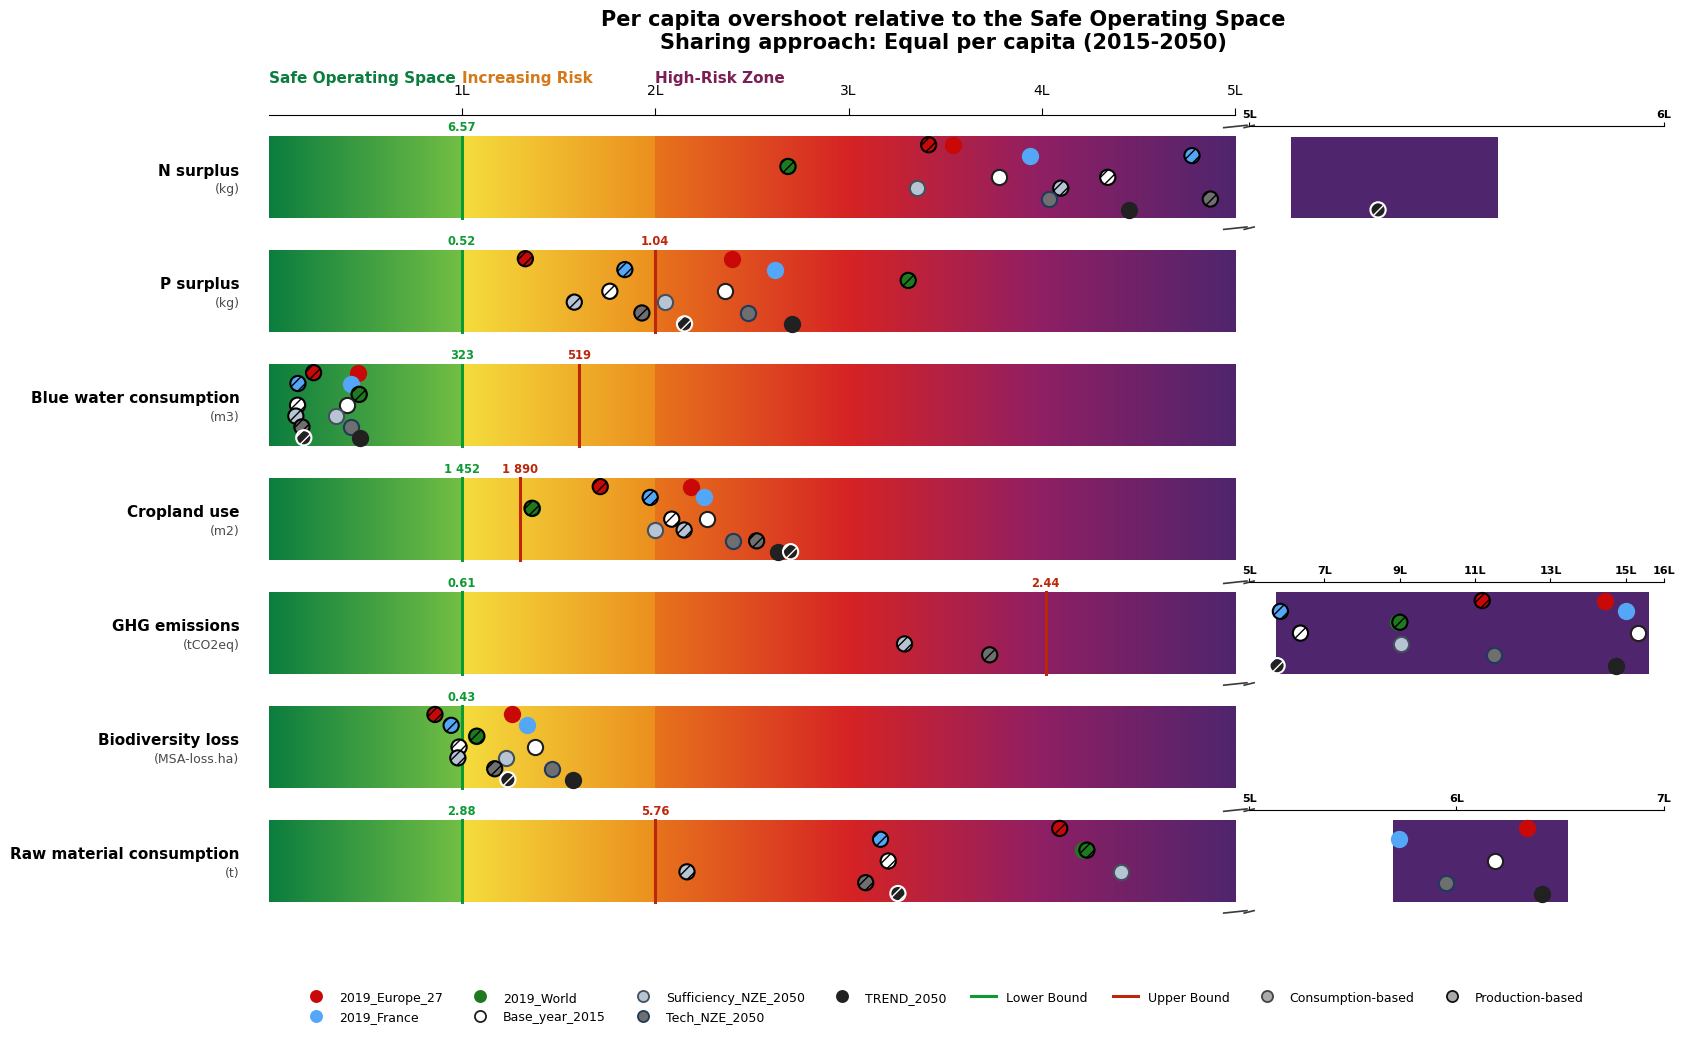

In [373]:
# ============================================================================
# 7. CALCUL + FIGURE
# ============================================================================

all_scenarios_data = []

for scenario_folder in SCENARIO_FOLDERS:
    print(f"  Traitement : {scenario_folder.name}")
    data = process_scenario_per_capita(
        scenario_folder, facteurs_carac_df, seuils_df, pop_df
    )
    print(f"    Sous-processus calculés : {list(data.keys())}")
    all_scenarios_data.append(data)

print(f"\n{len(all_scenarios_data)} scénarios traités.")

fig = create_overshoot_safe_space_figure(
    all_scenarios_data=all_scenarios_data,
    seuils_df=seuils_df,
    scenario_names=SCENARIO_NAMES,
    x_main_max=5.0
)

Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)
output_path = Path(FIGURES_DIR) / "overshoot_safe_operating_space_per_capita.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Figure sauvegardée : {output_path}")
plt.show()